In [25]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [26]:
# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

df = pd.read_csv("../dataset kaggle/city_day.csv")

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

DATASET LOADED
Shape: (29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

First 5 rows:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [27]:
# ============================================================
# CELL 3 — DATE PREPARATION
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

# Sort by city and date
df = df.sort_values(
    ["City", "Date"]
).reset_index(drop=True)

print("Date conversion completed.")
print("Data sorted by City and Date.")

display(
    df[["City", "Date", "AQI"]].head(10)
)

Date conversion completed.
Data sorted by City and Date.


,City,Date,AQI
0,Ahmedabad,2015-01-01,NaN
1,Ahmedabad,2015-01-02,NaN
2,Ahmedabad,2015-01-03,NaN
3,Ahmedabad,2015-01-04,NaN
4,Ahmedabad,2015-01-05,NaN
5,Ahmedabad,2015-01-06,NaN
6,Ahmedabad,2015-01-07,NaN
7,Ahmedabad,2015-01-08,NaN
8,Ahmedabad,2015-01-09,NaN
9,Ahmedabad,2015-01-10,NaN


In [28]:
# ============================================================
# CELL 4 — CREATE TOMORROW'S AQI TARGET
# ============================================================

df["Tomorrow_AQI"] = (
    df.groupby("City")["AQI"].shift(-1)
)

print("=" * 70)
print("TOMORROW AQI TARGET CREATED")
print("=" * 70)

display(
    df[
        ["City", "Date", "AQI", "Tomorrow_AQI"]
    ].head(20)
)

TOMORROW AQI TARGET CREATED


,City,Date,AQI,Tomorrow_AQI
0,Ahmedabad,2015-01-01,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN


In [29]:
# ============================================================
# CELL 5 — CHECK DATE GAPS
# ============================================================

df["Next_Date"] = (
    df.groupby("City")["Date"].shift(-1)
)

df["Days_To_Next"] = (
    df["Next_Date"] - df["Date"]
).dt.days

print("=" * 70)
print("DATE GAP CHECK")
print("=" * 70)

print(
    df["Days_To_Next"]
    .value_counts()
    .sort_index()
)

DATE GAP CHECK
Days_To_Next
1.0    29505
Name: count, dtype: int64


In [30]:
# ============================================================
# CELL 6 — CLEAN TOMORROW AQI TARGET
# ============================================================

before = len(df)

# Keep only rows where tomorrow is exactly the next day
df = df[df["Days_To_Next"] == 1].copy()

# Remove rows where tomorrow's AQI is unknown
df = df.dropna(subset=["Tomorrow_AQI"]).copy()

# Remove helper columns
df = df.drop(
    columns=["Next_Date", "Days_To_Next"]
)

df = df.reset_index(drop=True)

print("=" * 70)
print("TARGET CLEANING")
print("=" * 70)

print("Rows before:", before)
print("Rows after :", len(df))

print(
    "Missing Tomorrow_AQI:",
    df["Tomorrow_AQI"].isna().sum()
)

TARGET CLEANING
Rows before: 29531
Rows after : 24849
Missing Tomorrow_AQI: 0


In [31]:
# ============================================================
# CELL 7 — DEFINE FEATURES
# ============================================================

features = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3",
    "Benzene",
    "Toluene"
]

target = "Tomorrow_AQI"

print("=" * 70)
print("FEATURES AND TARGET")
print("=" * 70)

print("\nFeatures:")

for feature in features:
    print("-", feature)

print("\nNumber of features:", len(features))
print("Target:", target)

FEATURES AND TARGET

Features:
- PM2.5
- PM10
- NO
- NO2
- NOx
- NH3
- CO
- SO2
- O3
- Benzene
- Toluene

Number of features: 11
Target: Tomorrow_AQI


In [32]:
# ============================================================
# CELL 8 — TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Sort by date first
df = df.sort_values(
    ["Date", "City"]
).reset_index(drop=True)

# Get unique dates
unique_dates = sorted(
    df["Date"].unique()
)

# 80% of dates for training
split_index = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_index]

# Training = dates before split
train_df = df[
    df["Date"] < split_date
].copy()

# Testing = dates from split onward
test_df = df[
    df["Date"] >= split_date
].copy()

print("=" * 70)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 70)

print("Split date:", split_date)

print("\nTotal rows:", len(df))
print("Train rows:", len(train_df))
print("Test rows :", len(test_df))

print("\nTraining period:")
print(
    train_df["Date"].min(),
    "to",
    train_df["Date"].max()
)

print("\nTesting period:")
print(
    test_df["Date"].min(),
    "to",
    test_df["Date"].max()
)

common_dates = set(
    train_df["Date"]
).intersection(
    set(test_df["Date"])
)

print("\nCommon dates:", len(common_dates))

TIME-BASED TRAIN / TEST SPLIT
Split date: 2019-05-26 00:00:00

Total rows: 24849
Train rows: 16017
Test rows : 8832

Training period:
2015-01-01 00:00:00 to 2019-05-25 00:00:00

Testing period:
2019-05-26 00:00:00 to 2020-06-30 00:00:00

Common dates: 0


In [33]:
# ============================================================
# CELL 9 — MISSING VALUE IMPUTATION
# ============================================================

train_imp = train_df.copy()
test_imp = test_df.copy()

for col in features:

    # City-level median calculated ONLY from training data
    city_medians = (
        train_imp
        .groupby("City")[col]
        .median()
    )

    # Overall training median
    overall_median = (
        train_imp[col].median()
    )

    # -------------------------
    # TRAIN DATA
    # -------------------------

    train_imp[col] = (
        train_imp[col]
        .fillna(
            train_imp["City"].map(city_medians)
        )
        .fillna(overall_median)
    )

    # -------------------------
    # TEST DATA
    # -------------------------

    test_imp[col] = (
        test_imp[col]
        .fillna(
            test_imp["City"].map(city_medians)
        )
        .fillna(overall_median)
    )

print("=" * 70)
print("MISSING VALUE IMPUTATION")
print("=" * 70)

print("\nRemaining missing values — TRAIN:")
print(
    train_imp[features].isna().sum()
)

print("\nRemaining missing values — TEST:")
print(
    test_imp[features].isna().sum()
)

MISSING VALUE IMPUTATION

Remaining missing values — TRAIN:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64

Remaining missing values — TEST:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
dtype: int64


In [34]:
# ============================================================
# CELL 10 — CREATE X AND Y
# ============================================================

X_train = train_imp[features].copy()
X_test = test_imp[features].copy()

y_train = train_imp[target].copy()
y_test = test_imp[target].copy()

print("=" * 70)
print("FINAL ML DATASET")
print("=" * 70)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nMissing target values:")
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())

FINAL ML DATASET

X_train: (16017, 11)
X_test : (8832, 11)

y_train: (16017,)
y_test : (8832,)

Missing target values:
y_train: 0
y_test : 0


In [35]:
# ============================================================
# CELL 11 — OLS LINEAR REGRESSION
# ============================================================

from sklearn.linear_model import LinearRegression

# Create the OLS linear regression model
ols_model = LinearRegression()

# Train the model
ols_model.fit(X_train, y_train)

# Predict tomorrow's AQI
y_pred_ols = ols_model.predict(X_test)

print("=" * 70)
print("OLS LINEAR REGRESSION")
print("=" * 70)

print("Model trained successfully.")
print("Number of features:", X_train.shape[1])
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

OLS LINEAR REGRESSION
Model trained successfully.
Number of features: 11
Training samples: 16017
Testing samples: 8832


In [36]:
# ============================================================
# CELL 12 — OLS MODEL EVALUATION
# ============================================================

ols_mae = mean_absolute_error(
    y_test,
    y_pred_ols
)

ols_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ols
    )
)

ols_r2 = r2_score(
    y_test,
    y_pred_ols
)

print("=" * 70)
print("OLS MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE  : {ols_mae:.4f}")
print(f"RMSE : {ols_rmse:.4f}")
print(f"R²   : {ols_r2:.4f}")

OLS MODEL PERFORMANCE
MAE  : 25.6947
RMSE : 42.4752
R²   : 0.8331


In [37]:
# ============================================================
# CELL 13 — ACTUAL VS PREDICTED AQI
# ============================================================

results_ols = pd.DataFrame({
    "Actual_Tomorrow_AQI": y_test.values,
    "Predicted_Tomorrow_AQI": y_pred_ols
})

display(
    results_ols.head(20)
)

,Actual_Tomorrow_AQI,Predicted_Tomorrow_AQI
0,435.0,579.688888
1,106.0,118.763207
2,77.0,100.211096
3,92.0,84.517195
4,136.0,141.061834
5,113.0,126.391960
6,163.0,160.837497
7,120.0,145.503797
8,149.0,227.553989
9,114.0,144.675536


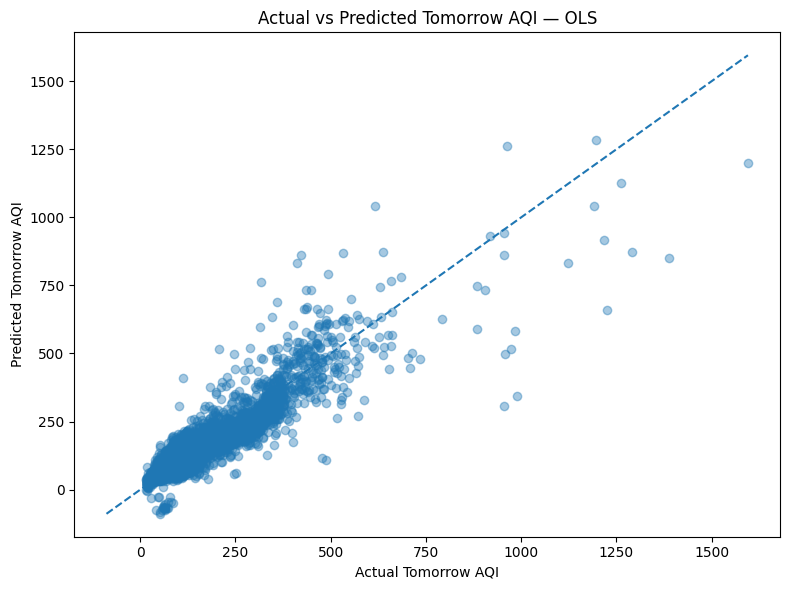

In [38]:
# ============================================================
# CELL 14 — ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ols,
    alpha=0.4
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    y_pred_ols.min()
)

max_value = max(
    y_test.max(),
    y_pred_ols.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")
plt.title("Actual vs Predicted Tomorrow AQI — OLS")

plt.tight_layout()

plt.show()

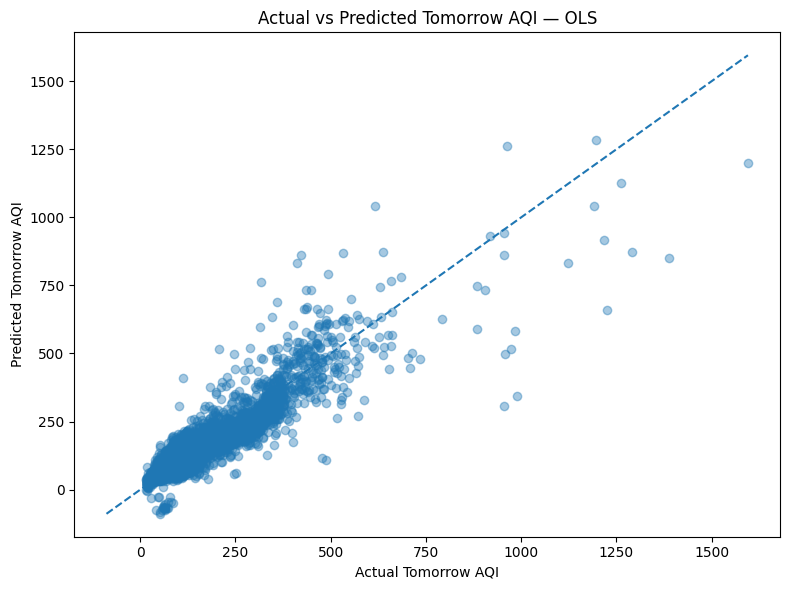

Graph saved successfully.


In [39]:
# ============================================================
# CELL 15 — SAVE OLS GRAPH
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_ols,
    alpha=0.4
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")
plt.title("Actual vs Predicted Tomorrow AQI — OLS")

plt.tight_layout()

plt.savefig(
    "../graphs/tomorrow_aqi_ols_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Graph saved successfully.")

In [40]:
# ============================================================
# CELL 16 — FEATURE STANDARDIZATION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the training scaler
X_test_scaled = scaler.transform(X_test)

print("=" * 70)
print("FEATURE STANDARDIZATION")
print("=" * 70)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

print("\nStandardization completed.")

FEATURE STANDARDIZATION
X_train_scaled shape: (16017, 11)
X_test_scaled shape : (8832, 11)

Standardization completed.


In [41]:
# ============================================================
# CELL 17 — LINEAR REGRESSION USING GRADIENT DESCENT
# ============================================================

# Convert data to NumPy arrays
X_gd = np.asarray(X_train_scaled, dtype=float)
y_gd = np.asarray(y_train, dtype=float)

X_test_gd = np.asarray(X_test_scaled, dtype=float)
y_test_gd = np.asarray(y_test, dtype=float)

# Add bias/intercept column
X_gd_bias = np.c_[
    np.ones(X_gd.shape[0]),
    X_gd
]

X_test_gd_bias = np.c_[
    np.ones(X_test_gd.shape[0]),
    X_test_gd
]

# Initialize parameters
weights = np.zeros(
    X_gd_bias.shape[1]
)

# Gradient descent settings
learning_rate = 0.01
epochs = 5000

# Store loss history
loss_history = []

# Number of training samples
n = len(y_gd)

print("=" * 70)
print("GRADIENT DESCENT LINEAR REGRESSION")
print("=" * 70)

print("Learning rate:", learning_rate)
print("Epochs:", epochs)
print("Parameters:", len(weights))

GRADIENT DESCENT LINEAR REGRESSION
Learning rate: 0.01
Epochs: 5000
Parameters: 12


In [42]:
# ============================================================
# CELL 18 — GRADIENT DESCENT TRAINING
# ============================================================

for epoch in range(epochs):

    # Predictions
    predictions = X_gd_bias @ weights

    # Errors
    errors = predictions - y_gd

    # Mean Squared Error
    mse = np.mean(errors ** 2)

    # Store loss
    loss_history.append(mse)

    # Gradient calculation
    gradient = (
        2 / n
    ) * (
        X_gd_bias.T @ errors
    )

    # Update weights
    weights = weights - learning_rate * gradient

print("=" * 70)
print("GRADIENT DESCENT TRAINING COMPLETED")
print("=" * 70)

print("Final training MSE:",
      loss_history[-1])

GRADIENT DESCENT TRAINING COMPLETED
Final training MSE: 5035.399521666207


In [44]:
# ============================================================
# CELL 19 — GRADIENT DESCENT PREDICTIONS
# ============================================================

y_pred_gd = X_test_gd_bias @ weights

print("=" * 70)
print("GRADIENT DESCENT PREDICTIONS")
print("=" * 70)

print("Predictions generated:", len(y_pred_gd))

comparison_gd = pd.DataFrame({
    "Actual_Tomorrow_AQI": y_test.values[:10],
    "Predicted_Tomorrow_AQI": y_pred_gd[:10]
})

display(comparison_gd)

GRADIENT DESCENT PREDICTIONS
Predictions generated: 8832


,Actual_Tomorrow_AQI,Predicted_Tomorrow_AQI
0,435.0,579.688888
1,106.0,118.763207
2,77.0,100.211096
3,92.0,84.517195
4,136.0,141.061834
5,113.0,126.391960
6,163.0,160.837497
7,120.0,145.503797
8,149.0,227.553989
9,114.0,144.675536


In [45]:
# ============================================================
# CELL 20 — GRADIENT DESCENT EVALUATION
# ============================================================

gd_mae = mean_absolute_error(
    y_test,
    y_pred_gd
)

gd_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gd
    )
)

gd_r2 = r2_score(
    y_test,
    y_pred_gd
)

print("=" * 70)
print("GRADIENT DESCENT MODEL PERFORMANCE")
print("=" * 70)

print(f"MAE  : {gd_mae:.4f}")
print(f"RMSE : {gd_rmse:.4f}")
print(f"R²   : {gd_r2:.4f}")

GRADIENT DESCENT MODEL PERFORMANCE
MAE  : 25.6947
RMSE : 42.4752
R²   : 0.8331


In [46]:
# ============================================================
# CELL 21 — OLS VS GRADIENT DESCENT
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "OLS Linear Regression",
        "Gradient Descent Linear Regression"
    ],
    "MAE": [
        ols_mae,
        gd_mae
    ],
    "RMSE": [
        ols_rmse,
        gd_rmse
    ],
    "R2": [
        ols_r2,
        gd_r2
    ]
})

print("=" * 70)
print("OLS VS GRADIENT DESCENT")
print("=" * 70)

display(comparison)

OLS VS GRADIENT DESCENT


,Model,MAE,RMSE,R2
0,OLS Linear Regression,25.694745,42.475218,0.833065
1,Gradient Descent Linear Regression,25.694745,42.475218,0.833065


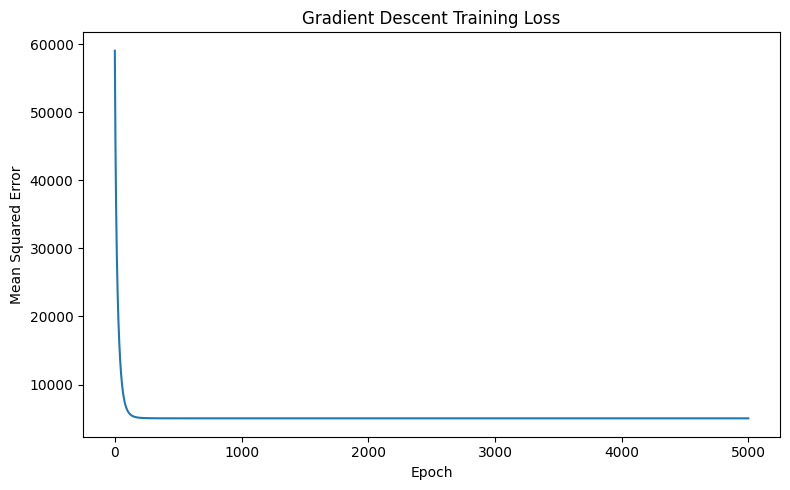

Loss graph saved successfully.


In [47]:
# ============================================================
# CELL 22 — GRADIENT DESCENT LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Training Loss")

plt.tight_layout()

plt.savefig(
    "../graphs/tomorrow_aqi_gradient_descent_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss graph saved successfully.")

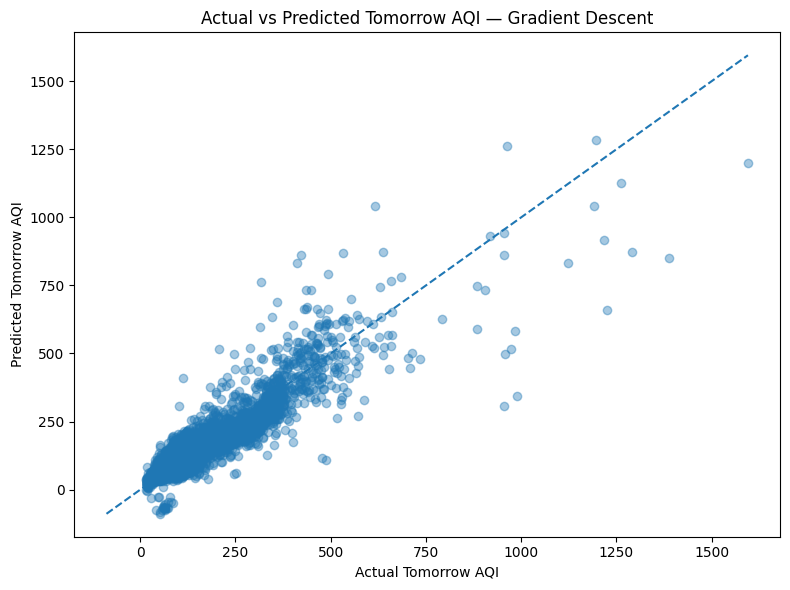

Gradient Descent graph saved successfully.


In [48]:
# ============================================================
# CELL 23 — GRADIENT DESCENT ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_gd,
    alpha=0.4
)

min_value = min(
    y_test.min(),
    y_pred_gd.min()
)

max_value = max(
    y_test.max(),
    y_pred_gd.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Tomorrow AQI")
plt.ylabel("Predicted Tomorrow AQI")
plt.title(
    "Actual vs Predicted Tomorrow AQI — Gradient Descent"
)

plt.tight_layout()

plt.savefig(
    "../graphs/tomorrow_aqi_gradient_descent_actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gradient Descent graph saved successfully.")

In [49]:
# ============================================================
# CELL 24 — OLS VS GRADIENT DESCENT COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "OLS Linear Regression",
        "Gradient Descent Linear Regression"
    ],
    "MAE": [
        ols_mae,
        gd_mae
    ],
    "RMSE": [
        ols_rmse,
        gd_rmse
    ],
    "R2": [
        ols_r2,
        gd_r2
    ]
})

print("=" * 70)
print("OLS VS GRADIENT DESCENT")
print("=" * 70)

display(comparison)

OLS VS GRADIENT DESCENT


,Model,MAE,RMSE,R2
0,OLS Linear Regression,25.694745,42.475218,0.833065
1,Gradient Descent Linear Regression,25.694745,42.475218,0.833065


In [50]:
# ============================================================
# CELL 25 — SAVE MODEL COMPARISON
# ============================================================

comparison.to_csv(
    "../graphs/tomorrow_aqi_ols_vs_gradient_descent.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


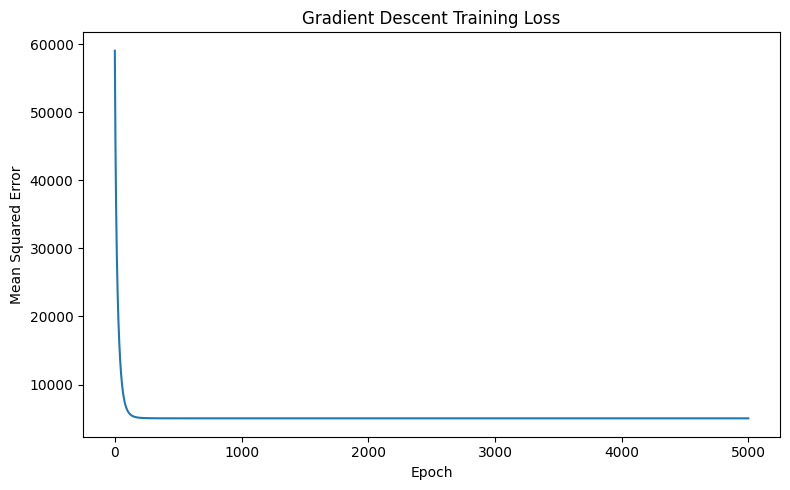

Loss graph saved successfully.


In [51]:
# ============================================================
# CELL 26 — GRADIENT DESCENT LOSS CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent Training Loss")

plt.tight_layout()

plt.savefig(
    "../graphs/tomorrow_aqi_gradient_descent_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss graph saved successfully.")

In [52]:
# ============================================================
# CELL 27 — OLS RESIDUAL ANALYSIS
# ============================================================

ols_residuals = y_test.values - y_pred_ols

print("=" * 70)
print("OLS RESIDUAL ANALYSIS")
print("=" * 70)

print("Mean residual:", np.mean(ols_residuals))
print("Std residual :", np.std(ols_residuals))
print("Min residual :", np.min(ols_residuals))
print("Max residual :", np.max(ols_residuals))

OLS RESIDUAL ANALYSIS
Mean residual: -4.3075290944821205
Std residual : 42.25623435851839
Min residual : -445.2494551347892
Max residual : 649.8465640808993


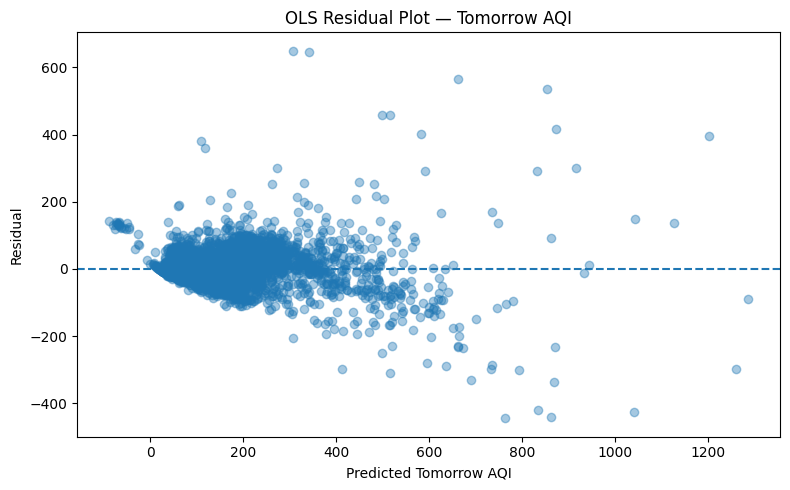

Residual plot saved successfully.


In [53]:
# ============================================================
# CELL 28 — OLS RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_ols,
    ols_residuals,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Tomorrow AQI")
plt.ylabel("Residual")
plt.title("OLS Residual Plot — Tomorrow AQI")

plt.tight_layout()

plt.savefig(
    "../graphs/tomorrow_aqi_ols_residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Residual plot saved successfully.")

In [54]:
# ============================================================
# CELL 29 — SAVE FINAL W3 RESULTS
# ============================================================

final_results = pd.DataFrame({
    "Model": [
        "OLS Linear Regression",
        "Gradient Descent Linear Regression"
    ],
    "MAE": [
        ols_mae,
        gd_mae
    ],
    "RMSE": [
        ols_rmse,
        gd_rmse
    ],
    "R2": [
        ols_r2,
        gd_r2
    ]
})

final_results.to_csv(
    "../graphs/tomorrow_aqi_w3_results.csv",
    index=False
)

print("=" * 70)
print("W3 RESULTS SAVED")
print("=" * 70)

display(final_results)

W3 RESULTS SAVED


,Model,MAE,RMSE,R2
0,OLS Linear Regression,25.694745,42.475218,0.833065
1,Gradient Descent Linear Regression,25.694745,42.475218,0.833065
